# Cross-model feature-importance stability

This notebook looks for features that are consistently ignored or weak across the production XGBoost regressors stored in S3. It compares the full-dataset, five-season, and three-season models **separately for each prediction target**.

The analysis deliberately does not recommend deleting a feature based on one model's `feature_importances_`. Tree importance can split credit unpredictably between correlated features, and XGBoost's column subsampling can leave useful variables unused in one fit. The workflow is therefore:

1. Load the latest valid model bundle from every configured production prefix.
2. Extract split count, gain, cover, and total gain for every feature in each model schema—including explicit zeros for unused features.
3. Measure rank and top-feature stability across training windows, separately for `TOTAL_POINTS` and `LINE_ERROR`.
4. Produce a conservative review shortlist, not an automatic deletion list.
5. Optionally verify shortlisted features with permutation importance on games strictly after each model's training cutoff.
6. Retrain and compare walk-forward performance after removing small batches.


In [8]:
from __future__ import annotations

import math
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from nba_ou.config.odds_columns import total_line_col
from nba_ou.config.settings import SETTINGS
from nba_ou.utils.s3_models import (
    list_s3_objects,
    make_s3_client,
    read_s3_json_object,
    read_s3_object_bytes,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
print(f"Project root: {PROJECT_ROOT}")
print(f"S3 bucket: {SETTINGS.s3_bucket}")
print(f"AWS region: {SETTINGS.s3_aws_region}")


Project root: /home/adrian_alvarez/Projects/NBA_over_under_predictor
S3 bucket: adrian-nba-model-registry-eu-west-1
AWS region: eu-west-1


## Controls

Using the latest model from each configured prefix gives six complementary views without allowing repeated snapshots of one training window to dominate the result. Increase `MAX_BUNDLES_PER_PREFIX` if you also want stability across retraining dates.

The shortlist thresholds are intentionally conservative. A feature must exist in enough comparable models and be unused or near the bottom repeatedly. Schema absence alone is **not** evidence that a feature is useless.


In [9]:
MODEL_PREFIXES = list(SETTINGS.prediction_model_prefixes)
MAX_BUNDLES_PER_PREFIX = 1

# Native-importance shortlist thresholds.
MIN_MODEL_COVERAGE_RATE = 0.67
ZERO_GAIN_RATE_FOR_REVIEW = 0.80
BOTTOM_RANK_FRACTION = 0.90  # 0.90 means median rank is in the bottom 10%.
MAX_TOP_QUARTILE_RATE = 0.0
TOP_K_FOR_STABILITY = 100
TOP_N_TO_PLOT = 30

# Optional held-out permutation validation. Keep False until EVALUATION_DATA_PATH
# points to data that was not used to fit the models being evaluated.
RUN_PERMUTATION_IMPORTANCE = False
EVALUATION_DATA_PATH = (
    PROJECT_ROOT / "data/train_data/test_predict_data_20260611.csv"
)
PERMUTATION_SAMPLE_SIZE = 750
PERMUTATION_REPEATS = 3
MAX_PERMUTATION_FEATURES_PER_MODEL = 200
PERMUTATION_RANDOM_STATE = 42
NEGLIGIBLE_MAE_INCREASE = 0.02

if not MODEL_PREFIXES:
    raise ValueError("No model prefixes are configured in [PredictionModels].")
display(pd.DataFrame({"configured_s3_prefix": MODEL_PREFIXES}))


,configured_s3_prefix
0,models/total_points_full_dataset/production/
1,models/total_points_last_5_seasons/production/
2,models/total_points_last_3_seasons/production/
3,models/line_error_full_dataset/production/
4,models/line_error_last_5_seasons/production/
5,models/line_error_last_3_seasons/production/


## Discover and load S3 model bundles

A valid bundle consists of `name.json` plus adjacent `name.meta.json`. Authentication, region, and bucket come from the same settings used by the prediction pipeline. Set `S3_AWS_PROFILE` to override the configured local AWS profile; an empty value uses the ambient AWS credential chain.


In [10]:
def nested_value(data: dict, *path: str):
    current = data
    for key in path:
        if not isinstance(current, dict):
            return None
        current = current.get(key)
    return current


def infer_target(metadata: dict) -> str:
    explicit_paths = (
        ("target",),
        ("target_column",),
        ("model", "target"),
        ("model", "target_column"),
        ("training_metrics", "target"),
        ("training_metrics", "target_column"),
    )
    for path in explicit_paths:
        value = nested_value(metadata, *path)
        if isinstance(value, str) and value.strip():
            return value.strip().upper()

    model = metadata.get("model") or {}
    signature = " ".join(
        str(model.get(key) or "").lower()
        for key in ("name", "model_type", "prediction_source")
    )
    if "total_points" in signature:
        return "TOTAL_POINTS"
    if any(token in signature for token in ("line_error", "error_line", "diff_from_line")):
        return "LINE_ERROR"
    return "UNKNOWN"


def discover_model_bundles(s3_client, bucket: str, prefix: str, limit: int = 1) -> list[dict]:
    objects = list_s3_objects(s3_client=s3_client, bucket=bucket, prefix=prefix)
    object_map = {str(obj["Key"]): obj for obj in objects}
    candidates = []
    for key, obj in object_map.items():
        if not key.endswith(".json") or key.endswith(".meta.json"):
            continue
        meta_key = f"{key[:-len('.json')]}.meta.json"
        if meta_key not in object_map:
            continue
        candidates.append(
            {
                "prefix": prefix,
                "model_key": key,
                "meta_key": meta_key,
                "last_modified": obj.get("LastModified"),
            }
        )
    candidates.sort(
        key=lambda item: (item["last_modified"], item["model_key"]),
        reverse=True,
    )
    return candidates[:limit]


def load_s3_bundle(s3_client, bucket: str, spec: dict) -> dict:
    metadata = read_s3_json_object(
        s3_client=s3_client, bucket=bucket, key=spec["meta_key"]
    )
    model_bytes = read_s3_object_bytes(
        s3_client=s3_client, bucket=bucket, key=spec["model_key"]
    )
    model = XGBRegressor()
    model.load_model(bytearray(model_bytes))

    feature_names = nested_value(metadata, "schema", "feature_names")
    if not isinstance(feature_names, list) or not feature_names:
        feature_names = model.get_booster().feature_names
    if not feature_names:
        raise ValueError(f"No feature names found for {spec['model_key']}")
    feature_names = [str(feature) for feature in feature_names]

    prefix_parts = [part for part in spec["prefix"].split("/") if part]
    window = prefix_parts[-2] if prefix_parts[-1] == "production" else prefix_parts[-1]
    model_name = str(nested_value(metadata, "model", "name") or Path(spec["model_key"]).stem)
    model_id = f"{window}:{model_name}"
    return {
        **spec,
        "model_id": model_id,
        "model_name": model_name,
        "window": window,
        "target": infer_target(metadata),
        "model": model,
        "metadata": metadata,
        "feature_names": feature_names,
        "train_games": nested_value(metadata, "training_metrics", "train_games"),
        "train_date_min": nested_value(metadata, "training_metrics", "train_date_min"),
        "train_date_max": nested_value(metadata, "training_metrics", "train_date_max"),
        "cv_mae": nested_value(metadata, "training_metrics", "cv_mae"),
        "final_test_mae": nested_value(metadata, "training_metrics", "final_test_mae"),
    }


In [11]:
s3 = make_s3_client(
    profile=SETTINGS.s3_aws_profile,
    region=SETTINGS.s3_aws_region,
)

bundle_specs = []
discovery_errors = []
for prefix in MODEL_PREFIXES:
    try:
        discovered = discover_model_bundles(
            s3, SETTINGS.s3_bucket, prefix, MAX_BUNDLES_PER_PREFIX
        )
        if not discovered:
            discovery_errors.append({"prefix": prefix, "error": "No valid bundle found"})
        bundle_specs.extend(discovered)
    except Exception as exc:
        discovery_errors.append({"prefix": prefix, "error": repr(exc)})

if discovery_errors:
    print("Discovery warnings:")
    display(pd.DataFrame(discovery_errors))
if not bundle_specs:
    raise RuntimeError("No S3 model bundles could be discovered.")

artifacts = []
load_errors = []
for spec in bundle_specs:
    try:
        artifacts.append(load_s3_bundle(s3, SETTINGS.s3_bucket, spec))
    except Exception as exc:
        load_errors.append({"model_key": spec["model_key"], "error": repr(exc)})

if load_errors:
    print("Load warnings:")
    display(pd.DataFrame(load_errors))
if not artifacts:
    raise RuntimeError("No models were loaded successfully.")

inventory = pd.DataFrame(
    [
        {
            "model_id": artifact["model_id"],
            "target": artifact["target"],
            "window": artifact["window"],
            "n_features": len(artifact["feature_names"]),
            "train_games": artifact["train_games"],
            "train_date_min": artifact["train_date_min"],
            "train_date_max": artifact["train_date_max"],
            "cv_mae": artifact["cv_mae"],
            "final_test_mae": artifact["final_test_mae"],
            "model_key": artifact["model_key"],
        }
        for artifact in artifacts
    ]
).sort_values(["target", "train_games", "model_id"])
display(inventory)


,model_id,target,window,n_features,train_games,train_date_min,train_date_max,cv_mae,final_test_mae,model_key
5,line_error_last_3_seasons:three_seasons_xgb_line_error_10_06_26,LINE_ERROR,line_error_last_3_seasons,2050,2500,2024-10-30T00:00:00,2026-06-10T00:00:00,13.158441,13.873357,models/line_error_last_3_seasons/production/three_seasons_xgb_line_error_10_06_26.json
4,line_error_last_5_seasons:five_seasons_xgb_line_error_10_06_26,LINE_ERROR,line_error_last_5_seasons,2050,5000,2022-03-24T00:00:00,2026-06-10T00:00:00,13.348198,13.799303,models/line_error_last_5_seasons/production/five_seasons_xgb_line_error_10_06_26.json
3,line_error_full_dataset:all_seasons_xgb_line_error_10_06_26,LINE_ERROR,line_error_full_dataset,1366,6750,2021-03-02T00:00:00,2026-06-10T00:00:00,12.924685,13.487921,models/line_error_full_dataset/production/all_seasons_xgb_line_error_10_06_26.json
2,total_points_last_3_seasons:three_seasons_xgb_total_points_10_06_26,TOTAL_POINTS,total_points_last_3_seasons,2051,2500,2024-10-30T00:00:00,2026-06-10T00:00:00,13.453838,13.556583,models/total_points_last_3_seasons/production/three_seasons_xgb_total_points_10_06_26.json
1,total_points_last_5_seasons:five_seasons_xgb_total_points_10_06_26,TOTAL_POINTS,total_points_last_5_seasons,2051,5100,2022-03-11T00:00:00,2026-06-10T00:00:00,13.251482,11.492277,models/total_points_last_5_seasons/production/five_seasons_xgb_total_points_10_06_26.json
0,total_points_full_dataset:full_xgb_total_points_10_06_26,TOTAL_POINTS,total_points_full_dataset,1355,7297,2020-12-28T00:00:00,2026-06-10T00:00:00,13.394214,13.756663,models/total_points_full_dataset/production/full_xgb_total_points_10_06_26.json


## Native XGBoost importance

`gain` measures the average loss reduction from splits using a feature; `total_gain` accumulates it; `weight` counts splits; and `cover` measures affected observations. Missing entries from `Booster.get_score()` are restored as explicit zeros so genuinely unused schema features remain visible. Values are normalized within each model before cross-model comparison.


In [12]:
IMPORTANCE_TYPES = ("gain", "total_gain", "weight", "cover")


def align_xgb_score(score: dict, feature_names: list[str]) -> pd.Series:
    aligned = pd.Series(0.0, index=feature_names, dtype=float)
    for key, value in score.items():
        feature = key
        match = re.fullmatch(r"f(\d+)", str(key))
        if match and key not in aligned.index:
            position = int(match.group(1))
            if position < len(feature_names):
                feature = feature_names[position]
        if feature in aligned.index:
            aligned.loc[feature] = float(value)
    return aligned


def extract_native_importance(artifact: dict) -> pd.DataFrame:
    features = artifact["feature_names"]
    booster = artifact["model"].get_booster()
    frame = pd.DataFrame({"feature": features})
    for importance_type in IMPORTANCE_TYPES:
        values = align_xgb_score(
            booster.get_score(importance_type=importance_type), features
        )
        frame[importance_type] = frame["feature"].map(values).fillna(0.0)
        total = float(frame[importance_type].sum())
        frame[f"{importance_type}_norm"] = (
            frame[importance_type] / total if total > 0 else 0.0
        )
    frame["used"] = frame["weight"] > 0
    frame["gain_rank_fraction"] = (
        frame["gain_norm"].rank(method="average", ascending=False) / len(frame)
    )
    frame["in_top_quartile"] = frame["gain_rank_fraction"] <= 0.25
    frame["in_top_100"] = frame["gain_rank_fraction"] <= min(1.0, 100 / len(frame))
    frame["model_id"] = artifact["model_id"]
    frame["target"] = artifact["target"]
    frame["window"] = artifact["window"]
    return frame


importance_long = pd.concat(
    [extract_native_importance(artifact) for artifact in artifacts],
    ignore_index=True,
)

model_usage = (
    importance_long.groupby(["target", "model_id"], as_index=False)
    .agg(
        schema_features=("feature", "size"),
        used_features=("used", "sum"),
        zero_gain_features=("gain", lambda values: int((values <= 0).sum())),
    )
)
model_usage["used_feature_rate"] = model_usage["used_features"] / model_usage["schema_features"]
display(model_usage.sort_values(["target", "used_feature_rate"]))


,target,model_id,schema_features,used_features,zero_gain_features,used_feature_rate
1,LINE_ERROR,line_error_last_3_seasons:three_seasons_xgb_line_error_10_06_26,2050,212,1838,0.103415
0,LINE_ERROR,line_error_full_dataset:all_seasons_xgb_line_error_10_06_26,1366,330,1036,0.241581
2,LINE_ERROR,line_error_last_5_seasons:five_seasons_xgb_line_error_10_06_26,2050,536,1514,0.261463
4,TOTAL_POINTS,total_points_last_3_seasons:three_seasons_xgb_total_points_10_06_26,2051,190,1861,0.092638
5,TOTAL_POINTS,total_points_last_5_seasons:five_seasons_xgb_total_points_10_06_26,2051,518,1533,0.252560
3,TOTAL_POINTS,total_points_full_dataset:full_xgb_total_points_10_06_26,1355,630,725,0.464945


In [13]:
def feature_family(feature: str) -> str:
    name = feature.upper()
    rules = (
        ("roster_continuity", ("ROSTER_",)),
        ("injuries_availability", ("INJUR", "AVAILABILITY")),
        ("players", ("PLAYER", "TOP1_", "TOP2_", "TOP3_")),
        ("odds_market", ("TOTAL_LINE", "MONEYLINE", "SPREAD", "ODDS_", "_PRICE_", "PCT_BETS", "PCT_MONEY")),
        ("referees", ("REFEREE", "OFFICIAL")),
        ("travel_rest", ("TRAVEL", "REST", "DISTANCE", "TIMEZONE")),
        ("pace_efficiency", ("PACE", "RATING", "EFFICIENCY", "TS_PCT")),
        ("team_form_boxscore", ("PTS", "REB", "AST", "FG", "FT", "TOV", "STL", "BLK")),
        ("schedule_season", ("GAME_NUMBER", "PLAYOFF", "SEASON", "MONTH", "WEEK", "DAY")),
        ("team_identity", ("TEAM_ID", "TEAM_CATEGORY", "IS_TEAM_")),
    )
    for family, tokens in rules:
        if any(token in name for token in tokens):
            return family
    return "other"


target_model_counts = inventory.groupby("target")["model_id"].nunique().to_dict()
importance_summary = (
    importance_long.groupby(["target", "feature"], as_index=False)
    .agg(
        models_present=("model_id", "nunique"),
        models_used=("used", "sum"),
        used_rate_when_present=("used", "mean"),
        zero_gain_rate=("gain", lambda values: float((values <= 0).mean())),
        median_gain_norm=("gain_norm", "median"),
        mean_gain_norm=("gain_norm", "mean"),
        max_gain_norm=("gain_norm", "max"),
        median_total_gain_norm=("total_gain_norm", "median"),
        median_weight_norm=("weight_norm", "median"),
        median_gain_rank_fraction=("gain_rank_fraction", "median"),
        top_quartile_rate=("in_top_quartile", "mean"),
        top_100_rate=("in_top_100", "mean"),
    )
)
importance_summary["target_model_count"] = importance_summary["target"].map(target_model_counts)
importance_summary["schema_presence_rate"] = (
    importance_summary["models_present"] / importance_summary["target_model_count"]
)
importance_summary["feature_family"] = importance_summary["feature"].map(feature_family)

minimum_models = importance_summary["target_model_count"].map(
    lambda count: max(2, math.ceil(count * MIN_MODEL_COVERAGE_RATE))
)
enough_models = importance_summary["models_present"] >= minimum_models
strong_unused = enough_models & (importance_summary["used_rate_when_present"] == 0)
consistently_low = (
    enough_models
    & (importance_summary["zero_gain_rate"] >= ZERO_GAIN_RATE_FOR_REVIEW)
    & (importance_summary["median_gain_rank_fraction"] >= BOTTOM_RANK_FRACTION)
    & (importance_summary["top_quartile_rate"] <= MAX_TOP_QUARTILE_RATE)
)
importance_summary["review_tier"] = np.select(
    [strong_unused, consistently_low],
    ["A_unused_in_every_comparable_model", "B_consistently_low_native_importance"],
    default="keep_or_insufficient_evidence",
)

candidate_summary = importance_summary[
    importance_summary["review_tier"] != "keep_or_insufficient_evidence"
].sort_values(
    ["target", "review_tier", "used_rate_when_present", "median_gain_norm", "feature"]
).reset_index(drop=True)

print(f"Features evaluated by target: {importance_summary.groupby('target')['feature'].nunique().to_dict()}")
print(f"Native review candidates by target/tier:")
display(
    candidate_summary.groupby(["target", "review_tier"]).size().rename("features").to_frame()
)


Features evaluated by target: {'LINE_ERROR': 2086, 'TOTAL_POINTS': 2089}
Native review candidates by target/tier:


,,features
target,review_tier,
LINE_ERROR,A_unused_in_every_comparable_model,737
TOTAL_POINTS,A_unused_in_every_comparable_model,553


## Important features and cross-window stability

The plots use median normalized gain across models for the same target. Pairwise Jaccard overlap answers a different question: do training windows select a similar top-`K` set? Low overlap warns that feature rankings are unstable and pruning should be even more conservative.


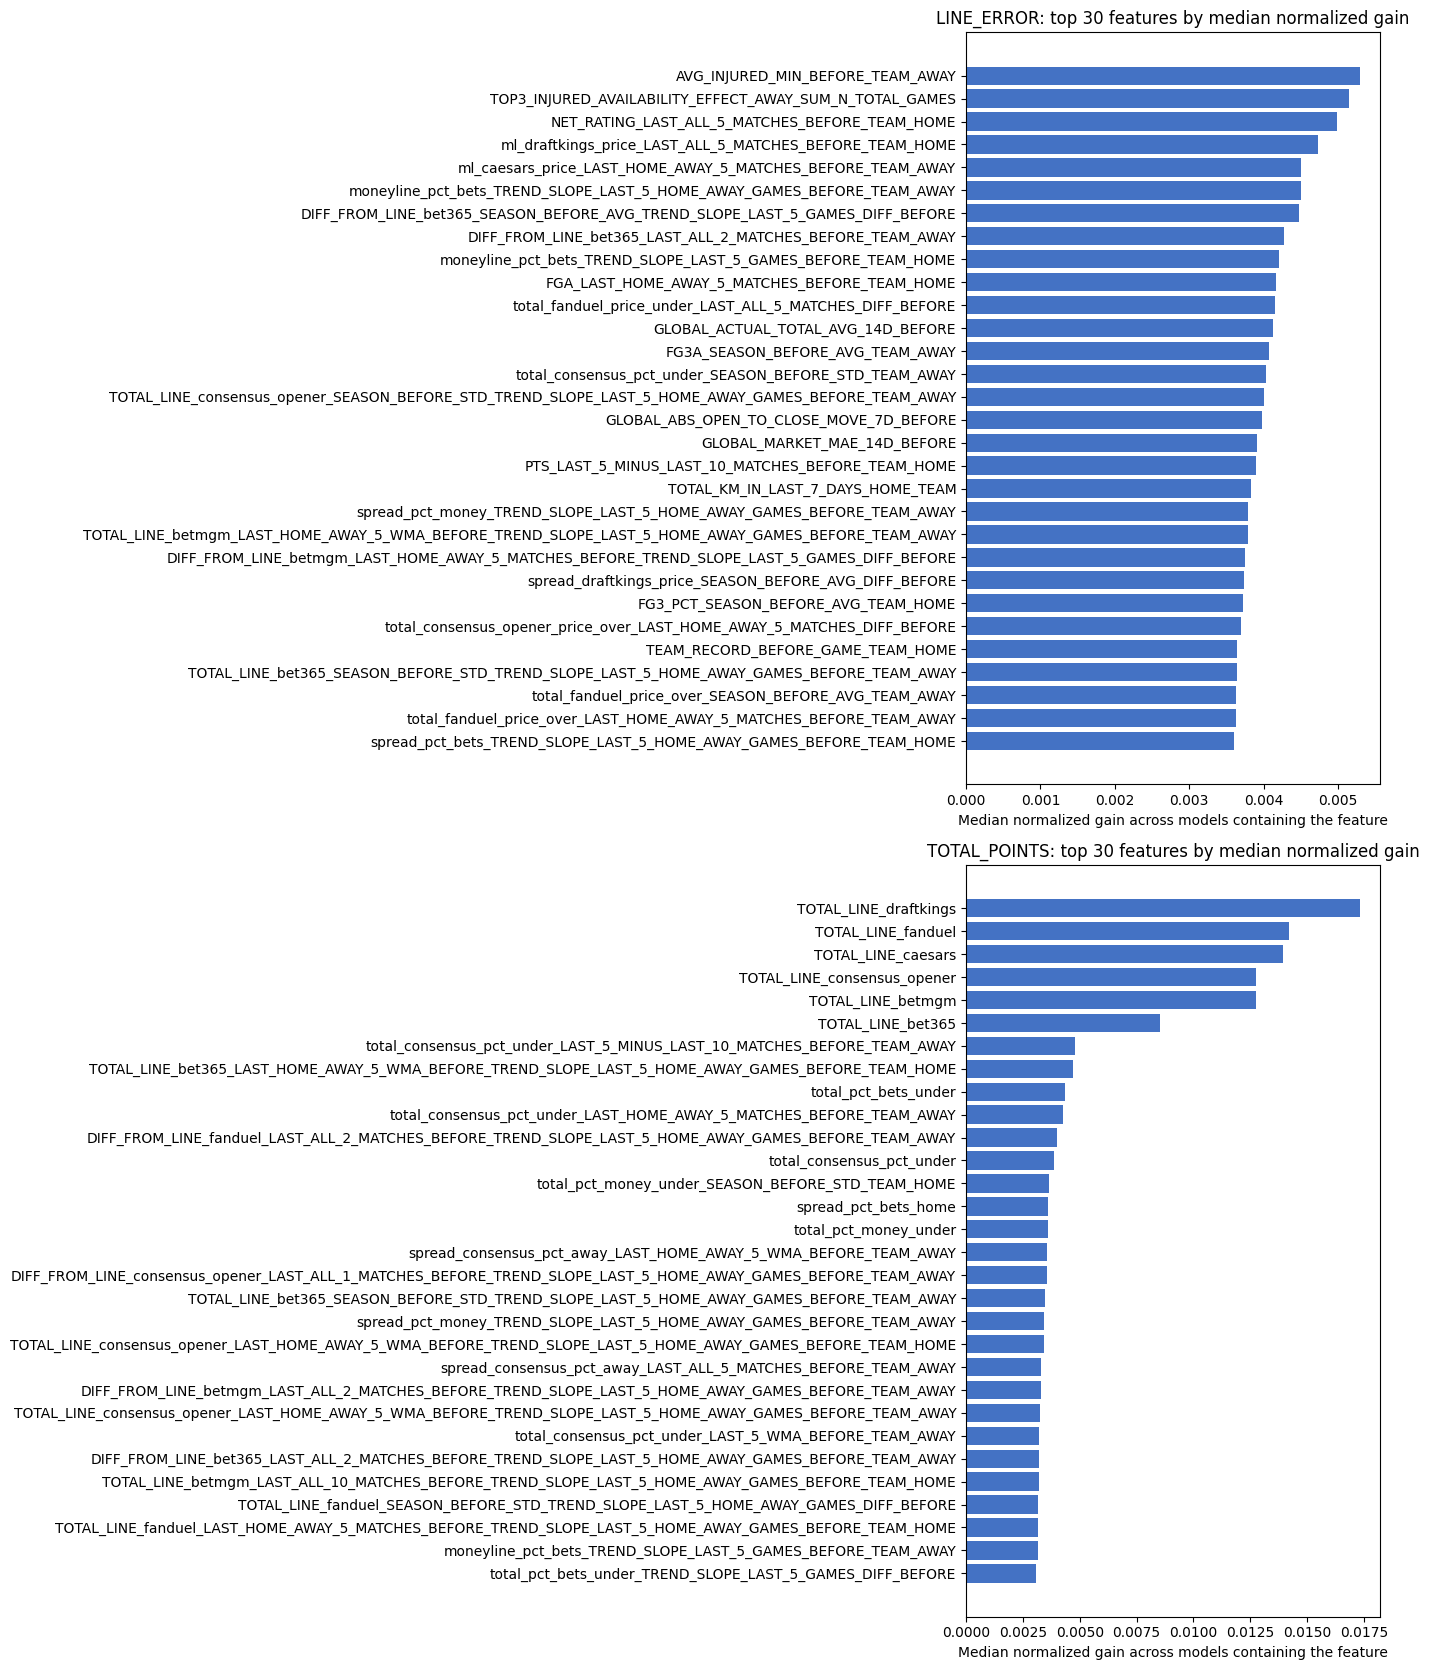

,target,model_left,model_right,top_k,intersection,jaccard
1,LINE_ERROR,line_error_full_dataset:all_seasons_xgb_line_error_10_06_26,line_error_last_5_seasons:five_seasons_xgb_line_error_10_06_26,100,9,0.047120
2,LINE_ERROR,line_error_last_3_seasons:three_seasons_xgb_line_error_10_06_26,line_error_last_5_seasons:five_seasons_xgb_line_error_10_06_26,100,11,0.058201
0,LINE_ERROR,line_error_full_dataset:all_seasons_xgb_line_error_10_06_26,line_error_last_3_seasons:three_seasons_xgb_line_error_10_06_26,100,15,0.081081
4,TOTAL_POINTS,total_points_full_dataset:full_xgb_total_points_10_06_26,total_points_last_5_seasons:five_seasons_xgb_total_points_10_06_26,100,10,0.052632
3,TOTAL_POINTS,total_points_full_dataset:full_xgb_total_points_10_06_26,total_points_last_3_seasons:three_seasons_xgb_total_points_10_06_26,100,11,0.058201
5,TOTAL_POINTS,total_points_last_3_seasons:three_seasons_xgb_total_points_10_06_26,total_points_last_5_seasons:five_seasons_xgb_total_points_10_06_26,100,15,0.081081


In [14]:
targets = sorted(importance_summary["target"].unique())
fig, axes = plt.subplots(
    len(targets), 1, figsize=(14, max(6, 0.28 * TOP_N_TO_PLOT * len(targets))), squeeze=False
)
for axis, target in zip(axes[:, 0], targets):
    top = (
        importance_summary[importance_summary["target"] == target]
        .nlargest(TOP_N_TO_PLOT, "median_gain_norm")
        .sort_values("median_gain_norm")
    )
    axis.barh(top["feature"], top["median_gain_norm"], color="#4472C4")
    axis.set_title(f"{target}: top {TOP_N_TO_PLOT} features by median normalized gain")
    axis.set_xlabel("Median normalized gain across models containing the feature")
plt.tight_layout()
plt.show()


def top_feature_set(model_frame: pd.DataFrame, top_k: int) -> set[str]:
    return set(model_frame.nlargest(top_k, "gain_norm")["feature"])


jaccard_rows = []
for target, target_frame in importance_long.groupby("target"):
    model_ids = sorted(target_frame["model_id"].unique())
    top_sets = {
        model_id: top_feature_set(
            target_frame[target_frame["model_id"] == model_id], TOP_K_FOR_STABILITY
        )
        for model_id in model_ids
    }
    for left_pos, left in enumerate(model_ids):
        for right in model_ids[left_pos + 1 :]:
            union = top_sets[left] | top_sets[right]
            intersection = top_sets[left] & top_sets[right]
            jaccard_rows.append(
                {
                    "target": target,
                    "model_left": left,
                    "model_right": right,
                    "top_k": TOP_K_FOR_STABILITY,
                    "intersection": len(intersection),
                    "jaccard": len(intersection) / len(union) if union else np.nan,
                }
            )
jaccard_stability = pd.DataFrame(jaccard_rows)
display(jaccard_stability.sort_values(["target", "jaccard"]))


In [18]:
candidate_columns = [
    "target",
    "feature",
    "feature_family",
    "review_tier",
    "models_present",
    "target_model_count",
    "schema_presence_rate",
    "models_used",
    "used_rate_when_present",
    "zero_gain_rate",
    "median_gain_norm",
    "max_gain_norm",
    "median_gain_rank_fraction",
    "top_quartile_rate",
]
display(candidate_summary[candidate_columns].head(200))

family_review = (
    candidate_summary.groupby(["target", "feature_family", "review_tier"], as_index=False)
    .agg(candidate_features=("feature", "nunique"))
    .sort_values(["target", "candidate_features"], ascending=[True, False])
)
display(family_review)

# Features shortlisted for both targets are especially useful ablation candidates,
# but only when both target families actually contained them in enough models.
cross_target_candidates = (
    candidate_summary.groupby("feature", as_index=False)
    .agg(
        targets_flagged=("target", "nunique"),
        targets=("target", lambda values: ",".join(sorted(set(values)))),
        worst_used_rate=("used_rate_when_present", "max"),
        max_native_gain=("max_gain_norm", "max"),
    )
    .sort_values(["targets_flagged", "max_native_gain"], ascending=[False, True])
)
display(cross_target_candidates.head(200))

# Strict intersection: present in every loaded target/window model and never
# used for a split in any of them. With the current registry this means all
# three TOTAL_POINTS models plus all three LINE_ERROR models.
loaded_targets = sorted(target_model_counts)
expected_models_across_targets = int(sum(target_model_counts.values()))
tier_a_candidates = candidate_summary[
    candidate_summary["review_tier"] == "A_unused_in_every_comparable_model"
]
unused_in_all_targets_and_windows = (
    tier_a_candidates.groupby("feature", as_index=False)
    .agg(
        feature_family=("feature_family", "first"),
        targets_flagged=("target", "nunique"),
        targets=("target", lambda values: ",".join(sorted(set(values)))),
        models_present=("models_present", "sum"),
        models_used=("models_used", "sum"),
        max_native_gain=("max_gain_norm", "max"),
    )
)
unused_in_all_targets_and_windows = unused_in_all_targets_and_windows[
    (unused_in_all_targets_and_windows["targets_flagged"] == len(loaded_targets))
    & (unused_in_all_targets_and_windows["models_present"] == expected_models_across_targets)
    & (unused_in_all_targets_and_windows["models_used"] == 0)
].sort_values(["feature_family", "feature"]).reset_index(drop=True)

print(
    f"Strict all-target/all-window unused features: "
    f"{len(unused_in_all_targets_and_windows)} across "
    f"{expected_models_across_targets} models ({', '.join(loaded_targets)})."
)
display(
    unused_in_all_targets_and_windows.groupby("feature_family")
    .size()
    .sort_values(ascending=False)
    .rename("unused_features")
    .to_frame()
)
display(unused_in_all_targets_and_windows)


,target,feature,feature_family,review_tier,models_present,target_model_count,schema_presence_rate,models_used,used_rate_when_present,zero_gain_rate,median_gain_norm,max_gain_norm,median_gain_rank_fraction,top_quartile_rate
0,LINE_ERROR,AVG_INJURED_DEF_RATING_BEFORE_TEAM_AWAY,injuries_availability,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
1,LINE_ERROR,AVG_INJURED_OFF_RATING_BEFORE_TEAM_HOME,injuries_availability,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
2,LINE_ERROR,AVG_INJURED_PACE_PER40_BEFORE_TEAM_HOME,injuries_availability,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
3,LINE_ERROR,AVG_INJURED_PTS_BEFORE_TEAM_HOME,injuries_availability,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
4,LINE_ERROR,AVG_INJURED_TS_PCT_BEFORE_TEAM_AWAY,injuries_availability,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,LINE_ERROR,FG_PCT_LAST_ALL_5_MATCHES_BEFORE_TEAM_AWAY,team_form_boxscore,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
196,LINE_ERROR,FG_PCT_LAST_HOME_AWAY_5_MATCHES_BEFORE_TEAM_AWAY,team_form_boxscore,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
197,LINE_ERROR,FG_PCT_LAST_HOME_AWAY_5_MATCHES_BEFORE_TEAM_HOME,team_form_boxscore,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0
198,LINE_ERROR,FG_PCT_SEASON_BEFORE_AVG_TEAM_HOME,team_form_boxscore,A_unused_in_every_comparable_model,3,3,1.0,0,0.0,1.0,0.0,0.0,0.621157,0.0


,target,feature_family,review_tier,candidate_features
1,LINE_ERROR,odds_market,A_unused_in_every_comparable_model,325
6,LINE_ERROR,team_form_boxscore,A_unused_in_every_comparable_model,205
0,LINE_ERROR,injuries_availability,A_unused_in_every_comparable_model,68
2,LINE_ERROR,other,A_unused_in_every_comparable_model,66
4,LINE_ERROR,players,A_unused_in_every_comparable_model,32
5,LINE_ERROR,schedule_season,A_unused_in_every_comparable_model,27
3,LINE_ERROR,pace_efficiency,A_unused_in_every_comparable_model,10
7,LINE_ERROR,travel_rest,A_unused_in_every_comparable_model,4
9,TOTAL_POINTS,odds_market,A_unused_in_every_comparable_model,256
14,TOTAL_POINTS,team_form_boxscore,A_unused_in_every_comparable_model,152


,feature,targets_flagged,targets,worst_used_rate,max_native_gain
6,AVG_INJURED_PTS_BEFORE_TEAM_HOME,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
8,AVG_POINTS_CONCEDED_AT_HOME_BEFORE_GAME,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
10,BACK_TO_BACK_BEFORE,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
13,BENCH_AVG_PTS_PER_MIN_BEFORE_TEAM_HOME,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
20,DIFF_FROM_LINE_bet365_LAST_5_MINUS_LAST_10_MATCHES_BEFORE_TEAM_AWAY,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
...,...,...,...,...,...
540,TOTAL_LINE_bet365_LAST_ALL_5_MATCHES_BEFORE_TEAM_AWAY,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
547,TOTAL_LINE_bet365_LAST_HOME_AWAY_5_MATCHES_BEFORE_TREND_SLOPE_LAST_5_GAMES_BEFORE_TEAM_AWAY,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
551,TOTAL_LINE_bet365_SEASON_BEFORE_AVG_TREND_SLOPE_LAST_5_GAMES_DIFF_BEFORE,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0
552,TOTAL_LINE_bet365_SEASON_BEFORE_STD_TEAM_AWAY,2,"LINE_ERROR,TOTAL_POINTS",0.0,0.0


Strict all-target/all-window unused features: 364 across 6 models (LINE_ERROR, TOTAL_POINTS).


,unused_features
feature_family,
odds_market,179
team_form_boxscore,89
injuries_availability,34
other,33
schedule_season,13
players,9
pace_efficiency,5
travel_rest,2


,feature,feature_family,targets_flagged,targets,models_present,models_used,max_native_gain
0,AVG_INJURED_PTS_BEFORE_TEAM_HOME,injuries_availability,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
1,N_INJURED_PLAYERS_BEFORE_TEAM_AWAY,injuries_availability,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
2,N_INJURED_PLAYERS_BEFORE_TEAM_HOME,injuries_availability,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
3,TOP1_INJURED_PLAYER_DEF_RATING_BEFORE_TEAM_HOME,injuries_availability,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
4,TOP1_INJURED_PLAYER_MIN_BEFORE_TEAM_AWAY,injuries_availability,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
...,...,...,...,...,...,...,...
359,PTS_LAST_5_WMA_BEFORE_TEAM_HOME,team_form_boxscore,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
360,PTS_TREND_SLOPE_LAST_10_GAMES_BEFORE_TEAM_AWAY,team_form_boxscore,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
361,TOTAL_KM_IN_LAST_1_DAYS_AWAY_TEAM,team_form_boxscore,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0
362,REST_DAYS_BEFORE_MATCH_TEAM_AWAY,travel_rest,2,"LINE_ERROR,TOTAL_POINTS",6,0,0.0


## Optional held-out permutation validation

Native zero gain means a tree never split on that feature; it does not prove the feature adds no predictive value when correlated substitutes exist. The next cell optionally permutes only the native shortlist and measures the increase in MAE. It uses rows strictly after each model's `train_date_max`.

Only enable this when the configured CSV contains genuinely unseen games and matches the model schema. A positive `mae_increase` means permutation harmed performance and the feature carried useful information. Values close to or below zero support—but still do not prove—removal.


In [16]:
def numeric_xgb_frame(frame: pd.DataFrame) -> pd.DataFrame:
    converted = frame.copy()
    non_numeric = []
    for column in converted.columns:
        if pd.api.types.is_numeric_dtype(converted[column]) or pd.api.types.is_bool_dtype(converted[column]):
            continue
        numeric = pd.to_numeric(converted[column], errors="coerce")
        if int(numeric.notna().sum()) != int(converted[column].notna().sum()):
            non_numeric.append(column)
        else:
            converted[column] = numeric
    if non_numeric:
        raise TypeError(
            "Evaluation data contains non-numeric model features with unknown training encoding: "
            f"{non_numeric[:20]}"
        )
    return converted


def target_for_artifact(frame: pd.DataFrame, artifact: dict) -> pd.Series:
    if artifact["target"] == "TOTAL_POINTS":
        if "TOTAL_POINTS" not in frame.columns:
            raise KeyError("TOTAL_POINTS is missing from evaluation data.")
        return pd.to_numeric(frame["TOTAL_POINTS"], errors="coerce")
    if artifact["target"] == "LINE_ERROR":
        if "LINE_ERROR" in frame.columns:
            return pd.to_numeric(frame["LINE_ERROR"], errors="coerce")
        line_column = total_line_col()
        if "TOTAL_POINTS" not in frame.columns or line_column not in frame.columns:
            raise KeyError(
                f"LINE_ERROR requires LINE_ERROR or TOTAL_POINTS plus {line_column}."
            )
        return pd.to_numeric(frame["TOTAL_POINTS"], errors="coerce") - pd.to_numeric(
            frame[line_column], errors="coerce"
        )
    raise ValueError(f"Unsupported target: {artifact['target']}")


def candidate_permutation_importance(
    artifact: dict,
    raw_evaluation: pd.DataFrame,
    candidate_features: list[str],
) -> tuple[pd.DataFrame, dict]:
    features = artifact["feature_names"]
    missing = sorted(set(features) - set(raw_evaluation.columns))
    if missing:
        raise KeyError(f"{len(missing)} required model features are missing; first: {missing[:20]}")
    if "GAME_DATE" not in raw_evaluation.columns:
        raise KeyError("GAME_DATE is required for a post-training holdout.")

    dates = pd.to_datetime(raw_evaluation["GAME_DATE"], errors="coerce")
    cutoff = pd.to_datetime(artifact["train_date_max"], errors="coerce")
    if pd.isna(cutoff):
        raise ValueError("Model metadata has no valid train_date_max.")
    holdout_mask = dates > cutoff
    holdout = raw_evaluation.loc[holdout_mask].copy()
    if holdout.empty:
        raise ValueError(f"No evaluation games occur after training cutoff {cutoff.date()}.")

    y = target_for_artifact(holdout, artifact)
    valid_target = y.notna()
    holdout = holdout.loc[valid_target].copy()
    y = y.loc[valid_target]
    if len(holdout) > PERMUTATION_SAMPLE_SIZE:
        sampled_index = holdout.sample(
            PERMUTATION_SAMPLE_SIZE, random_state=PERMUTATION_RANDOM_STATE
        ).index
        holdout = holdout.loc[sampled_index]
        y = y.loc[sampled_index]

    X = numeric_xgb_frame(holdout[features])
    baseline_predictions = artifact["model"].predict(X)
    baseline_mae = mean_absolute_error(y, baseline_predictions)
    selected = [feature for feature in candidate_features if feature in features]
    selected = selected[:MAX_PERMUTATION_FEATURES_PER_MODEL]
    rng = np.random.default_rng(PERMUTATION_RANDOM_STATE)
    rows = []
    X_permuted = X.copy()
    for feature in selected:
        original = X_permuted[feature].copy()
        repeated_increases = []
        for _ in range(PERMUTATION_REPEATS):
            X_permuted[feature] = rng.permutation(original.to_numpy())
            permuted_predictions = artifact["model"].predict(X_permuted)
            repeated_increases.append(
                mean_absolute_error(y, permuted_predictions) - baseline_mae
            )
        X_permuted[feature] = original
        rows.append(
            {
                "model_id": artifact["model_id"],
                "target": artifact["target"],
                "feature": feature,
                "baseline_mae": baseline_mae,
                "mae_increase_mean": float(np.mean(repeated_increases)),
                "mae_increase_std": float(np.std(repeated_increases, ddof=0)),
                "holdout_games": len(holdout),
                "holdout_start": dates.loc[holdout.index].min(),
                "holdout_end": dates.loc[holdout.index].max(),
            }
        )
    diagnostics = {
        "model_id": artifact["model_id"],
        "target": artifact["target"],
        "train_cutoff": cutoff,
        "holdout_games": len(holdout),
        "baseline_mae": baseline_mae,
        "features_permuted": len(selected),
    }
    return pd.DataFrame(rows), diagnostics


permutation_long = pd.DataFrame()
permutation_diagnostics = pd.DataFrame()
if RUN_PERMUTATION_IMPORTANCE:
    if not EVALUATION_DATA_PATH.exists():
        raise FileNotFoundError(EVALUATION_DATA_PATH)
    evaluation_df = pd.read_csv(EVALUATION_DATA_PATH, low_memory=False)
    permutation_frames = []
    diagnostic_rows = []
    permutation_errors = []
    for artifact in artifacts:
        shortlisted = candidate_summary.loc[
            candidate_summary["target"] == artifact["target"], "feature"
        ].tolist()
        try:
            result, diagnostics = candidate_permutation_importance(
                artifact, evaluation_df, shortlisted
            )
            permutation_frames.append(result)
            diagnostic_rows.append(diagnostics)
        except Exception as exc:
            permutation_errors.append({"model_id": artifact["model_id"], "error": repr(exc)})
    if permutation_frames:
        permutation_long = pd.concat(permutation_frames, ignore_index=True)
    permutation_diagnostics = pd.DataFrame(diagnostic_rows)
    display(permutation_diagnostics)
    if permutation_errors:
        print("Permutation warnings:")
        display(pd.DataFrame(permutation_errors))
    if not permutation_long.empty:
        permutation_summary = (
            permutation_long.groupby(["target", "feature"], as_index=False)
            .agg(
                models_permuted=("model_id", "nunique"),
                mean_mae_increase=("mae_increase_mean", "mean"),
                max_mae_increase=("mae_increase_mean", "max"),
                positive_effect_rate=("mae_increase_mean", lambda values: float((values > 0).mean())),
            )
        )
        permutation_summary["permutation_supports_removal"] = (
            permutation_summary["max_mae_increase"] <= NEGLIGIBLE_MAE_INCREASE
        )
        display(
            permutation_summary.sort_values(
                ["permutation_supports_removal", "max_mae_increase"],
                ascending=[False, True],
            ).head(200)
        )
else:
    print("Permutation importance skipped. Set RUN_PERMUTATION_IMPORTANCE = True after validating the holdout CSV.")


Permutation importance skipped. Set RUN_PERMUTATION_IMPORTANCE = True after validating the holdout CSV.


## Export and decision protocol

The CSVs below are audit artifacts. `native_feature_removal_candidates.csv` is a **review list**, not a list to drop automatically. A safe reduction experiment removes a small batch, retrains with the same time splits and seeds, and accepts the reduction only if recent-window MAE/RMSE and over/under accuracy remain stable.

Recommended order:

1. Start with tier A features that are unused in every comparable model.
2. Prefer features also negligible under post-training permutation.
3. Review correlated families together; individual permutation can underrate interchangeable variables.
4. Remove at most 5–10% of features per ablation round.
5. Re-run walk-forward validation across the same full/5-season/3-season windows.
6. Keep the smaller schema only when degradation is within a tolerance chosen before the experiment.


In [17]:
OUTPUT_DIR = PROJECT_ROOT / "lab/feature_selection_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

inventory.to_csv(OUTPUT_DIR / "s3_model_inventory.csv", index=False)
model_usage.to_csv(OUTPUT_DIR / "model_feature_usage_summary.csv", index=False)
importance_summary.to_csv(OUTPUT_DIR / "native_feature_importance_stability.csv", index=False)
candidate_summary.to_csv(OUTPUT_DIR / "native_feature_removal_candidates.csv", index=False)
unused_in_all_targets_and_windows.to_csv(
    OUTPUT_DIR / "unused_in_all_targets_and_windows.csv", index=False
)
jaccard_stability.to_csv(OUTPUT_DIR / "top_feature_jaccard_stability.csv", index=False)
if not permutation_long.empty:
    permutation_long.to_csv(OUTPUT_DIR / "candidate_permutation_importance.csv", index=False)

print(f"Saved analysis tables to: {OUTPUT_DIR}")


Saved analysis tables to: /home/adrian_alvarez/Projects/NBA_over_under_predictor/lab/feature_selection_outputs
